# Redes Convolucionales con Fashion MNIST

**Integrantes del equipo:**
- Alpiste Tuesta, Fernando Miguel
- Contreras Meza, Jeison Josimar

**Curso:** Deep Learning — 2026


---
## **1. Librerias**

Importamos las librerías necesarias:
- **TensorFlow / Keras**: framework principal para construir y entrenar la CNN.
- **NumPy**: operaciones numéricas sobre arrays.
- **Pandas**: manejo tabular de resultados de experimentación.
- **Matplotlib / Seaborn**: visualización de curvas de entrenamiento, heatmaps y matriz de confusión.
- **scikit-learn**: métricas adicionales (classification report, confusion matrix, train_test_split estratificado).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU disponible:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU disponible: True


## **2. Carga y Preparación de Datos**

**Fashion MNIST** contiene 70,000 imágenes en escala de grises (28×28 píxeles) distribuidas en 10 categorías de ropa:

| Clase | Etiqueta |
|-------|----------|
| T-shirt/top | 0 |
| Trouser | 1 |
| Pullover | 2 |
| Dress | 3 |
| Coat | 4 |
| Sandal | 5 |
| Shirt | 6 |
| Sneaker | 7 |
| Bag | 8 |
| Ankle boot | 9 |

### Preprocesamiento aplicado
1. **Normalización [0, 1]**: dividir entre 255 escala los píxeles y estabiliza el entrenamiento, acelerando la convergencia.
2. **Reshape**: se agrega una dimensión de canal `(28, 28) → (28, 28, 1)`, necesaria para las capas `Conv2D`.
3. **Split estratificado (85/15)**: se usa `stratify=y` para mantener la proporción de clases en train y validación. El conjunto de test se mantiene **intacto** para la evaluación final.

### Capa convolucional (Conv2D)
Es una capa clave en redes convolucionales (CNN) que permite **extraer patrones espaciales** de las imágenes (bordes, formas, texturas). La arquitectura también incluirá otros tipos de capas.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train:      (51000, 28, 28, 1)  |  (51000,)
Validación: (9000, 28, 28, 1)    |  (9000,)
Test:       (10000, 28, 28, 1)   |  (10000,)

Distribución de clases en train:
  T-shirt/top    : 5100 muestras
  Trouser        : 5100 muestras
  Pullover       : 5100 muestras
  Dress          : 5100 muestras
  Coat           : 5100 muestras
  Sandal         : 5100 muestras
  Shirt          : 5100 muestras
  Sneaker        : 5100 muestras
  Bag            : 5100 muestras
  Ankle boot     : 5100 muestras


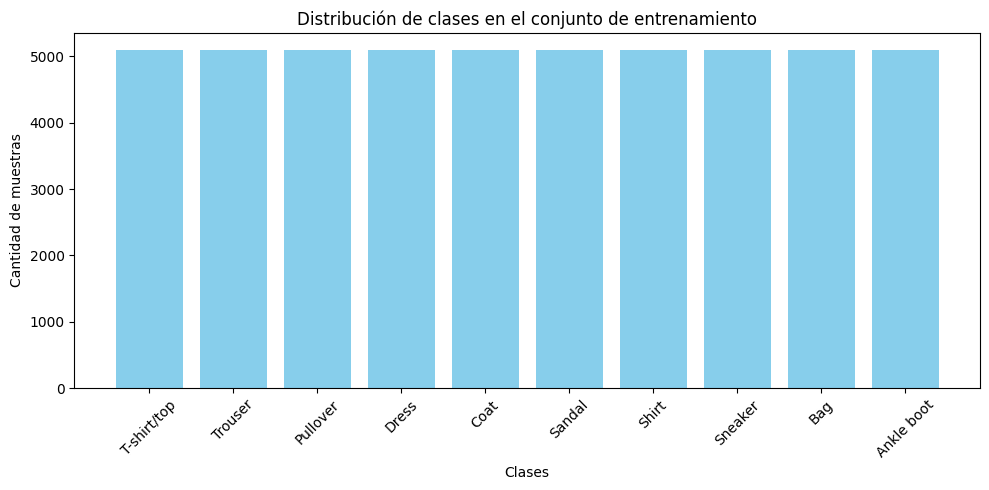

In [2]:
# Descarga y carga el dataset Fashion MNIST.
# Este dataset contiene imágenes de ropa (28x28 píxeles en escala de grises).
# Se divide en:
# X_train_full: imágenes de entrenamiento (60,000)
# y_train_full: etiquetas (clases) de esas imágenes
# X_test: imágenes de prueba (10,000)
# y_test: etiquetas de prueba

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# 1) Normalización [0, 1], pues:
# Los píxeles originalmente van de 0 a 255. (por eso dividimos)
# Esto ayuda a que el modelo aprenda mejor y más rápido.
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0

# 2) Reshape: agregar canal para Conv2D
# Convierte las imágenes de forma: (28, 28) → (28, 28, 1)
# Ese 1 representa el canal (escala de grises).
# Es necesario para usar capas convolucionales (Conv2D).
X_train_full = X_train_full[..., np.newaxis]   # (60000, 28, 28, 1)
X_test       = X_test[..., np.newaxis]         # (10000, 28, 28, 1)

# 3) Split estratificado train / validación (85% / 15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full   # garantiza proporciones iguales por clase
)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
# Mostrar tamaño de los datos
print(f'Train:      {X_train.shape}  |  {y_train.shape}')
print(f'Validación: {X_val.shape}    |  {y_val.shape}')
print(f'Test:       {X_test.shape}   |  {y_test.shape}')
print(f'\nDistribución de clases en train:')

# Contamos cuántos datos hay por clase
unique, counts = np.unique(y_train, return_counts=True)
# Mostramos la distribución en texto
for u, c in zip(unique, counts):
    print(f'  {CLASS_NAMES[u]:15s}: {c} muestras') # imprimos las clases


# ------------------------------------------------------------------------------
# Gráficamos barras de cantidad de cada clase
plt.figure(figsize=(10,5))
plt.bar(unique, counts, color='skyblue')

# ------------------------------------------------------------------------------
# Etiquetas
plt.xticks(unique, [CLASS_NAMES[i] for i in unique], rotation=45)
plt.xlabel('Clases')
plt.ylabel('Cantidad de muestras')
plt.title('Distribución de clases en el conjunto de entrenamiento')

plt.tight_layout()
plt.show()

**Gráficos de las clases de elementos de la data.**

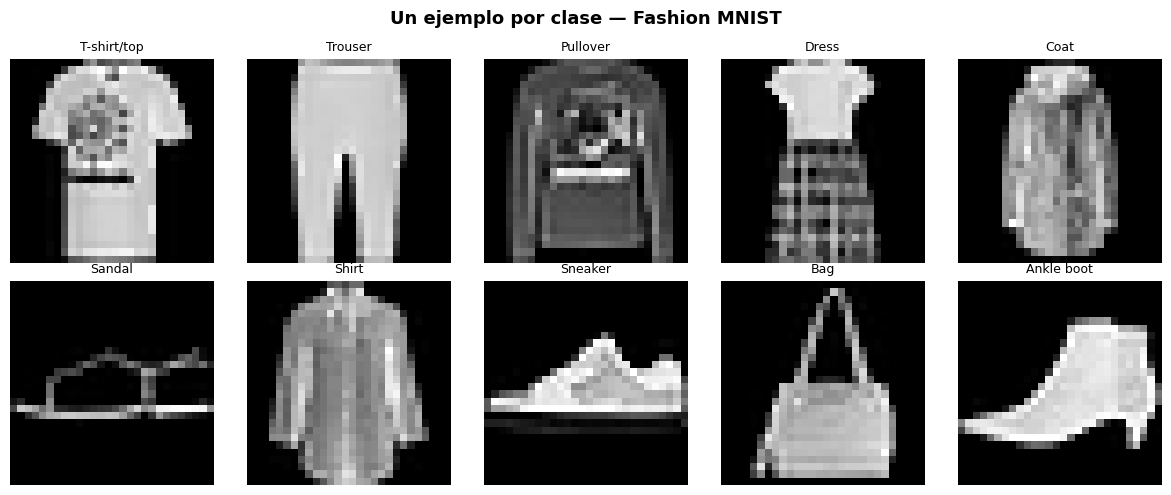

In [3]:
# Visualización de ejemplos del dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]   # un ejemplo de cada clase
    ax.imshow(X_train[idx, :, :, 0], cmap='gray')
    ax.set_title(CLASS_NAMES[i], fontsize=9)
    ax.axis('off')
plt.suptitle('Un ejemplo por clase — Fashion MNIST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## **3. Arquitectura CNN**

### Decisiones de diseño

Se utiliza una CNN con **3 bloques convolucionales progresivos (32 → 64 → 128 filtros)**.  
Las primeras capas capturan características simples (bordes, texturas), mientras que las más profundas aprenden patrones más complejos.

```
Entrada (28×28×1)
    │
    ├── Conv2D(32) → BN → Activ → MaxPool → Dropout
    ├── Conv2D(64) → BN → Activ → MaxPool → Dropout
    ├── Conv2D(128) → BN → Activ → GlobalAvgPool
    ├── Dense(128) → Activ → Dropout
    └── Dense(10) → Softmax
```

### Componentes clave

- **Conv2D (3×3, same)**: extrae características locales manteniendo dimensiones.
- **Batch Normalization**: estabiliza el entrenamiento y mejora la convergencia.
- **MaxPooling (2×2)**: reduce la dimensión espacial y el número de parámetros.
- **Dropout (0.3 / 0.5)**: ayuda a prevenir sobreajuste.
- **GlobalAveragePooling**: reduce parámetros frente a Flatten y mejora la generalización.
- **Softmax**: salida probabilística para clasificación multiclase.

### Inicialización y regularización

- **Inicialización**:
  - *He Normal* → ReLU / LeakyReLU  
  - *Glorot Uniform* → tanh / sigmoid  

- **Regularización aplicada**:
  - L2 (1e-4)
  - Dropout
  - Max-norm (opcional)

> La función `build_model()` permite configurar activación, regularización y restricciones para experimentar con distintas variantes de la arquitectura.


In [4]:
# La funcion buil_model es un constructor de arquitecturas CNN configurables
def build_model(activation='relu', l2_reg=1e-4, dropout_rate=0.3, use_maxnorm=True):

    # ----------------------------
    # ------ Configuraciones -----
    # ----------------------------

    # --- Config de (cómo empiezan los pesos):
    # Inicializacion segun tipo de activacion
    if activation in ['relu', 'leaky_relu']:
        initializer = 'he_normal'       # He para activaciones no saturadas
    else:
        initializer = 'glorot_uniform'  # Xavier para saturadas (sigmoid/tanh)
    # --- Config de (límites de crecimiento):
    # Restriccion Max-norm: limita la norma L2 de cada kernel a max_value=3
    # Previene pesos excesivamente grandes sin penalizar la funcion de perdida
    maxnorm_constraint = keras.constraints.MaxNorm(max_value=3.0) if use_maxnorm else None

    # --- Config de (activación dinámica):
    # decides: ReLU, LeakyReLU, tanh, etc.
    # Esto cambia cómo “responde” cada neurona/filtro.
    def get_activation():
        if activation == 'leaky_relu':
            return layers.LeakyReLU(negative_slope=0.1)  # pendiente 0.1 para valores negativos
        return layers.Activation(activation)

    # -------------------------------------------------
    # ------ Inicio de la Creacion del modelo CNN -----
    # -------------------------------------------------
    # 1.- Inicio de la Red Neuronal
    # La red neuronal creada tiene 3 bloques convolucionales (aqui dentro hay capas)
    # Cada bloque hace: Conv → Normaliza → Activa → Reduce → Regulariza
    # ---
    # Capa densa: 1 capa densa y que hace: Dense(128) → Dense(10)
    # Asi: combina todo lo aprendido y decide la clase final
    model = keras.Sequential(name=f'CNN_{activation}')


    # ── BLOQUE 1: 32 filtros (14x14 tras MaxPool) ──────────────────────────
    # que se hace: Conv → Normaliza → Activa → Reduce → Regulariza
    # aprende: bordes y líneas
    model.add(layers.Conv2D(
        32, (3, 3), padding='same',
        kernel_initializer=initializer,
        kernel_regularizer=regularizers.l2(l2_reg),
        kernel_constraint=maxnorm_constraint,
        input_shape=(28, 28, 1)
    ))
    model.add(layers.BatchNormalization())  # capa auxiliar
    model.add(get_activation())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))  # capa auxiliar
    model.add(layers.Dropout(dropout_rate)) # capa auxiliar

    # ── BLOQUE 2: 64 filtros (7x7 tras MaxPool) ───────────────────────────
    # que se hace: Conv → Normaliza → Activa → Reduce → Regulariza
    # aprende: formas y partes de objetos
    model.add(layers.Conv2D(
        64, (3, 3), padding='same',
        kernel_initializer=initializer,
        kernel_regularizer=regularizers.l2(l2_reg),
        kernel_constraint=maxnorm_constraint
    ))
    model.add(layers.BatchNormalization())  # capa auxiliar
    model.add(get_activation())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))  # capa auxiliar
    model.add(layers.Dropout(dropout_rate)) # capa auxiliar

    # ── BLOQUE 3: 128 filtros (GlobalAvgPool en lugar de Flatten) ─────────
    # que se hace: Conv → Normaliza → Activa → Reduce → Regulariza
    # aprende: objetos completos y conceptos
    model.add(layers.Conv2D(
        128, (3, 3), padding='same',
        kernel_initializer=initializer,
        kernel_regularizer=regularizers.l2(l2_reg),
        kernel_constraint=maxnorm_constraint
    ))
    model.add(layers.BatchNormalization())  # capa auxiliar
    model.add(get_activation())
    model.add(layers.GlobalAveragePooling2D())  # reduce (7x7x128) -> (128,)

    # ── CAPAS DENSAS (decisión) ──────────────────────────────────────────────────────
    # que se hace: Dense(128) → Dense(10)
    # aprende: combina todo lo aprendido y decide la clase final
    model.add(layers.Dense(
        128,
        kernel_initializer=initializer,
        kernel_regularizer=regularizers.l2(l2_reg),
        kernel_constraint=maxnorm_constraint
    ))
    model.add(get_activation())
    model.add(layers.Dropout(0.5))  # tasa mayor en capa densa

    # ── CAPA DE SALIDA: 10 clases con Softmax ─────────────────────────────
    model.add(layers.Dense(10, activation='softmax'))
    # ----- Termina la construccion -----
    # 2.- Retorna el modelo contruido
    return model

# -----------------------------------------------
# Vista previa de la arquitectura base (con ReLU)
preview = build_model(activation='relu')
preview.summary()
print(f'\nTotal de capas Conv2D: {sum(1 for l in preview.layers if isinstance(l, layers.Conv2D))}')
print(f'Total de parametros entrenables: {preview.count_params():,}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_relu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)


Total de capas Conv2D: 3
Total de parametros entrenables: 111,370


---
## **4. Compilación y Callbacks**

### Optimizadores evaluados

Se comparan distintos optimizadores para analizar su impacto en la convergencia y desempeño:

- **Adam**: convergencia rápida y estable (baseline).
- **SGD + momentum (0.9, Nesterov)**: mejor generalización en algunos casos.
- **RMSprop**: adapta el learning rate por parámetro.
- **Nadam**: variante de Adam con Nesterov.

### Configuración de entrenamiento

- **Loss**: `sparse_categorical_crossentropy` (clasificación multiclase con etiquetas enteras).
- **Métrica**: `accuracy`.

La función `compile_model()` permite seleccionar el optimizador y el learning rate de forma flexible.

### Callbacks

- **EarlyStopping (patience=10)**: detiene el entrenamiento si `val_loss` no mejora y restaura los mejores pesos.
- **ReduceLROnPlateau (patience=5)**: reduce el learning rate cuando la validación se estanca.

> La función `get_callbacks()` centraliza estas estrategias para mejorar la estabilidad y evitar sobreentrenamiento.

In [5]:
# =================================
# ===== Definimos 2 funciones =====
# =================================

# ---------------------------
# ----- Primera función -----
# ---------------------------

# La siguiente función recibe:
# model          : modelo Keras ya construido pero sin compilar
# optimizer_name : 'adam', 'sgd', 'rmsprop' o 'nadam'
# lr             : learning rate inicial (default 1e-3), controla la velocidad de aprendizaje

# Esta función compila el modelo, es decir, define cómo aprenderá durante el entrenamiento:
# - qué optimizador utilizar
# - qué función de pérdida minimizar
# - qué métricas evaluar

def compile_model(model, optimizer_name='adam', lr=1e-3):

    # ----- Definición de optimizadores -----
    # Se crea un diccionario que mapea nombres a instancias de optimizadores
    optimizers_map = {
        'adam': keras.optimizers.Adam(learning_rate=lr),
        # Adam: rápido y estable, usa momentos de primer y segundo orden

        'sgd': keras.optimizers.SGD(
            learning_rate=lr,
            momentum=0.9,
            nesterov=True
        ),
        # SGD con momentum: acumula dirección (evita zig-zag)
        # Nesterov: mejora la estimación del gradiente

        'rmsprop': keras.optimizers.RMSprop(learning_rate=lr),
        # RMSprop: adapta el learning rate por parámetro

        'nadam': keras.optimizers.Nadam(learning_rate=lr)
        # Nadam: combinación de Adam con Nesterov momentum
    }

    # ----- Compilación del modelo -----
    # En esta etapa NO se construye la red, sino que se define cómo se entrenará
    model.compile(
        optimizer=optimizers_map[optimizer_name],  # algoritmo de optimización
        loss='sparse_categorical_crossentropy',    # función de pérdida para clasificación multiclase con etiquetas enteras
        metrics=['accuracy']                       # métrica de evaluación (porcentaje de aciertos)
    )

    # Se devuelve el modelo listo para ser entrenado con model.fit()
    return model

# ---------------------------
# ----- Segunda función -----
# ---------------------------

# Devuelve una lista de callbacks para mejorar el entrenamiento del modelo:

# - EarlyStopping:
#   Detiene el entrenamiento si la pérdida en validación (val_loss) no mejora
#   durante un número determinado de épocas (patience=15).
#   Además, restaura automáticamente los pesos del mejor modelo encontrado.

# - ReduceLROnPlateau:
#   Reduce la tasa de aprendizaje (learning rate) cuando la métrica monitorizada
#   deja de mejorar. En este caso, reduce el LR a la mitad si val_loss no mejora
#   durante 5 épocas consecutivas.

def get_callbacks():
    return [
         # ----- Callback 1: EarlyStopping -----
        EarlyStopping(
            monitor='val_loss',          # métrica a observar (pérdida en validación)
            patience=10,                # número de épocas sin mejora antes de detener (profe entre 10 a 20)
            restore_best_weights=True, # recupera los mejores pesos encontrados
            verbose=1                  # muestra mensajes cuando se activa
        ),

        # ----- Callback 2: ReduceLROnPlateau -----
        ReduceLROnPlateau(
            monitor='val_loss',  # métrica a observar
            patience=5,          # espera 5 épocas sin mejora (profe entre 10 a 20)
            factor=0.5,          # reduce el learning rate a la mitad
            min_lr=1e-6,         # límite inferior del learning rate
            verbose=0            # no muestra mensajes
        )
    ]

---
## **5. Experimentación Sistemática**

### Principio de experimentación (*ceteris paribus*)

El objetivo es aislar el efecto de cada hiperparámetro variando **una sola variable a la vez**.

La experimentación se organiza en tres ejes:

| Eje | Variable modificada | Variables fijas |
|-----|---------------------|-----------------|
| **1** | Activación × Optimizador | CNN base, batch=64, epochs=25 |
| **2** | Batch size | Mejor configuración del Eje 1 |
| **3** | Arquitectura | Mejores configuraciones previas |

Esto permite comparar resultados de forma controlada.

### ¿Por qué se fijó `epochs=25` en todos los experimentos?

El número de épocas máximas **no es un hiperparámetro libre** en este proyecto, sino un techo de seguridad. El entrenamiento efectivo está completamente controlado por **Early Stopping (patience=10)**, que detiene el modelo automáticamente cuando `val_loss` deja de mejorar y restaura los mejores pesos (`restore_best_weights=True`).

Bajo este esquema, lo que realmente varía entre experimentos no es cuántas épocas se ejecutan, sino **cuándo para el early stopping**, y eso depende directamente de la activación, el optimizador, el batch size y la arquitectura — exactamente los ejes que sí estamos comparando.

Fijar `epochs=25` garantiza además que todos los experimentos tienen las **mismas condiciones de tiempo máximo**, lo que hace las comparaciones entre configuraciones más justas (ningún modelo tiene "más oportunidades" que otro). Variar este techo no aportaría información adicional mientras el early stopping se active antes del límite.

> **Nota:** en los resultados se observó que todos los experimentos llegaron a la epoch 25 sin que el early stopping se activara antes, lo que sugiere que con un techo mayor podría haberse obtenido mejor desempeño. Esto se discute en la sección 10.3 como posible mejora futura.





---

### **5.1 Eje 1 — Activación × Optimizador**

Se evalúan **4 funciones de activación × 4 optimizadores = 16 combinaciones**:

**Activaciones:**
- ReLU
- Leaky ReLU
- tanh
- sigmoid

**Optimizadores:**
- SGD
- Adam
- RMSprop
- Nadam

#### Configuración fija del experimento:
- Arquitectura CNN base (32 → 64 → 128 filtros)
- Batch size: 64
- Épocas máximas: 25
- EarlyStopping (patience=10)
- Regularización: BatchNorm, Dropout, L2 y MaxNorm

#### Métricas evaluadas:
- `val_accuracy`
- `val_loss`

Cada modelo se entrena desde cero para asegurar independencia entre experimentos.

---


In [6]:
# Grid de experimentos: 4 activaciones x 4 optimizadores = 16 configuraciones
activations = ['relu', 'leaky_relu', 'tanh', 'sigmoid']
optimizers  = ['adam', 'sgd', 'rmsprop', 'nadam']

results = []   # acumula resultados de cada experimento

for act in activations:
    for opt in optimizers:

        print(f'\n{"="*60}')
        print(f'  [EXP {len(results)+1:02d}/16]  activation={act:12s}  optimizer={opt}')
        print(f'{"="*60}')

        # Construir y compilar modelo fresco en cada iteracion
        model = build_model(activation=act)
        model = compile_model(model, optimizer_name=opt)

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=25,
            batch_size=64,
            callbacks=get_callbacks(),
            verbose=0   # silencioso para no saturar la salida
        )

        # Epoch real de parada (early stopping)
        stopped_epoch = len(history.history['loss'])

        # Metricas en el punto de parada (mejores pesos ya restaurados por EarlyStopping)
        train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
        val_loss,   val_acc   = model.evaluate(X_val,   y_val,   verbose=0)

        print(f'  Parada en epoch : {stopped_epoch}')
        print(f'  Train  -> loss: {train_loss:.4f}  |  acc: {train_acc:.4f}')
        print(f'  Val    -> loss: {val_loss:.4f}  |  acc: {val_acc:.4f}')

        results.append({
            'activation':    act,
            'optimizer':     opt,
            'stopped_epoch': stopped_epoch,
            'train_loss':    round(train_loss, 4),
            'train_acc':     round(train_acc,  4),
            'val_loss':      round(val_loss,   4),
            'val_acc':       round(val_acc,    4),
        })

# Tabla de resultados ordenada por val_acc descendente
df_results = pd.DataFrame(results).sort_values('val_acc', ascending=False).reset_index(drop=True)
print('\n' + '='*70)
print('TABLA COMPLETA DE RESULTADOS — ordenada por val_acc')
print('='*70)
print(df_results.to_string(index=True))


  [EXP 01/16]  activation=relu          optimizer=adam
Restoring model weights from the end of the best epoch: 20.
  Parada en epoch : 25
  Train  -> loss: 0.3028  |  acc: 0.9113
  Val    -> loss: 0.3165  |  acc: 0.9071

  [EXP 02/16]  activation=relu          optimizer=sgd
Restoring model weights from the end of the best epoch: 25.
  Parada en epoch : 25
  Train  -> loss: 0.6700  |  acc: 0.7764
  Val    -> loss: 0.6582  |  acc: 0.7889

  [EXP 03/16]  activation=relu          optimizer=rmsprop
Restoring model weights from the end of the best epoch: 24.
  Parada en epoch : 25
  Train  -> loss: 0.2783  |  acc: 0.9228
  Val    -> loss: 0.2943  |  acc: 0.9182

  [EXP 04/16]  activation=relu          optimizer=nadam
Restoring model weights from the end of the best epoch: 23.
  Parada en epoch : 25
  Train  -> loss: 0.2615  |  acc: 0.9263
  Val    -> loss: 0.2791  |  acc: 0.9201

  [EXP 05/16]  activation=leaky_relu    optimizer=adam
Restoring model weights from the end of the best epoch: 2

**Visualizaciones comparativas del grid**

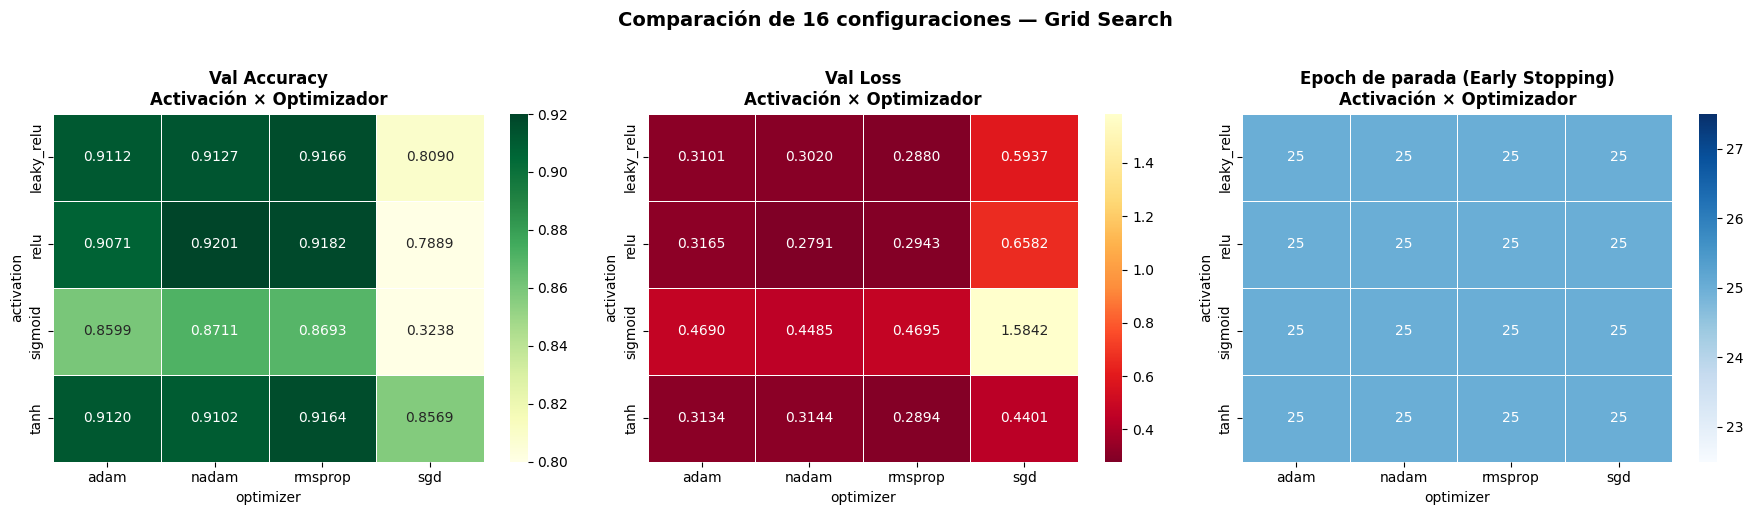


Top 5 configuraciones:
activation optimizer  val_acc  val_loss  stopped_epoch
      relu     nadam   0.9201    0.2791             25
      relu   rmsprop   0.9182    0.2943             25
leaky_relu   rmsprop   0.9166    0.2880             25
      tanh   rmsprop   0.9164    0.2894             25
leaky_relu     nadam   0.9127    0.3020             25


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap: val_accuracy
pivot_acc = df_results.pivot(index='activation', columns='optimizer', values='val_acc')
sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=axes[0], vmin=0.8)
axes[0].set_title('Val Accuracy\nActivación × Optimizador', fontweight='bold')

# Heatmap: val_loss
pivot_loss = df_results.pivot(index='activation', columns='optimizer', values='val_loss')
sns.heatmap(pivot_loss, annot=True, fmt='.4f', cmap='YlOrRd_r',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Val Loss\nActivación × Optimizador', fontweight='bold')

# Heatmap: stopped_epoch
pivot_ep = df_results.pivot(index='activation', columns='optimizer', values='stopped_epoch')
sns.heatmap(pivot_ep, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=axes[2])
axes[2].set_title('Epoch de parada (Early Stopping)\nActivación × Optimizador', fontweight='bold')

plt.suptitle('Comparación de 16 configuraciones — Grid Search', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nTop 5 configuraciones:')
print(df_results[['activation','optimizer','val_acc','val_loss','stopped_epoch']].head(5).to_string(index=False))

---
### **5.2 Eje 2 — Batch Size (ceteris paribus)**

**Hipótesis:** el batch size influye en la estabilidad del entrenamiento y la capacidad de generalización.

- **Batch pequeño (16–32):** gradientes más ruidosos → posible mejor generalización, pero entrenamiento más inestable.
- **Batch grande (128–256):** gradientes más estables → convergencia más rápida, pero posible sobreajuste.

---

### Protocolo experimental

- Se fija la **mejor combinación de activación y optimizador** del Eje 1.
- Se varía únicamente el batch size:  
  **[16, 32, 64, 128, 256]**
- Se mantienen constantes:
  - Arquitectura CNN (32 → 64 → 128)
  - Épocas máximas: 25
  - EarlyStopping (patience=10)
  - Regularización completa

---

### Métricas evaluadas
- `val_accuracy`
- `val_loss`
- Epoch de parada (convergencia)
- Diferencia train vs validation (sobreajuste)

---

In [8]:
# ── EJE 2: Experimento de Batch Size (ceteris paribus) ──────────────────────────
# Fijamos la mejor config del Eje 1
best_act = df_results.iloc[0]['activation']
best_opt = df_results.iloc[0]['optimizer']

batch_sizes = [16, 32, 64, 128, 256]
batch_results = []

print(f'Configuración fija: activation={best_act}, optimizer={best_opt}')
print(f'Batch sizes a probar: {batch_sizes}')
print('='*60)

for bs in batch_sizes:
    print(f'\n  [BATCH={bs}]  activation={best_act}  optimizer={best_opt}')

    model_bs = build_model(activation=best_act)
    model_bs = compile_model(model_bs, optimizer_name=best_opt)

    history_bs = model_bs.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=25,
        batch_size=bs,
        callbacks=get_callbacks(),
        verbose=0
    )

    stopped = len(history_bs.history['loss'])
    tr_loss, tr_acc = model_bs.evaluate(X_train, y_train, verbose=0)
    vl_loss, vl_acc = model_bs.evaluate(X_val,   y_val,   verbose=0)

    print(f'  Parada epoch: {stopped} | val_acc: {vl_acc:.4f} | val_loss: {vl_loss:.4f}')

    batch_results.append({
        'batch_size':    bs,
        'stopped_epoch': stopped,
        'train_loss':    round(tr_loss, 4),
        'train_acc':     round(tr_acc,  4),
        'val_loss':      round(vl_loss, 4),
        'val_acc':       round(vl_acc,  4),
    })

df_batch = pd.DataFrame(batch_results).sort_values('val_acc', ascending=False).reset_index(drop=True)
print('\n' + '='*60)
print('RESULTADOS EJE 2 — Batch Size (ordenados por val_acc)')
print('='*60)
print(df_batch.to_string(index=False))

best_batch = df_batch.iloc[0]['batch_size']
print(f'\n>>> Mejor batch size: {int(best_batch)}')


Configuración fija: activation=relu, optimizer=nadam
Batch sizes a probar: [16, 32, 64, 128, 256]

  [BATCH=16]  activation=relu  optimizer=nadam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Restoring model weights from the end of the best epoch: 25.
  Parada epoch: 25 | val_acc: 0.9183 | val_loss: 0.3146

  [BATCH=32]  activation=relu  optimizer=nadam
Restoring model weights from the end of the best epoch: 24.
  Parada epoch: 25 | val_acc: 0.9242 | val_loss: 0.2787

  [BATCH=64]  activation=relu  optimizer=nadam
Restoring model weights from the end of the best epoch: 25.
  Parada epoch: 25 | val_acc: 0.9208 | val_loss: 0.2858

  [BATCH=128]  activation=relu  optimizer=nadam
Restoring model weights from the end of the best epoch: 25.
  Parada epoch: 25 | val_acc: 0.9176 | val_loss: 0.2925

  [BATCH=256]  activation=relu  optimizer=nadam
Restoring model weights from the end of the best epoch: 22.
  Parada epoch: 25 | val_acc: 0.9123 | val_loss: 0.2970

RESULTADOS EJE 2 — Batch Size (ordenados por val_acc)
 batch_size  stopped_epoch  train_loss  train_acc  val_loss  val_acc
         32             25      0.2533     0.9304    0.2787   0.9242
         64             25      0

**Visualizaciones de graficos de barras**

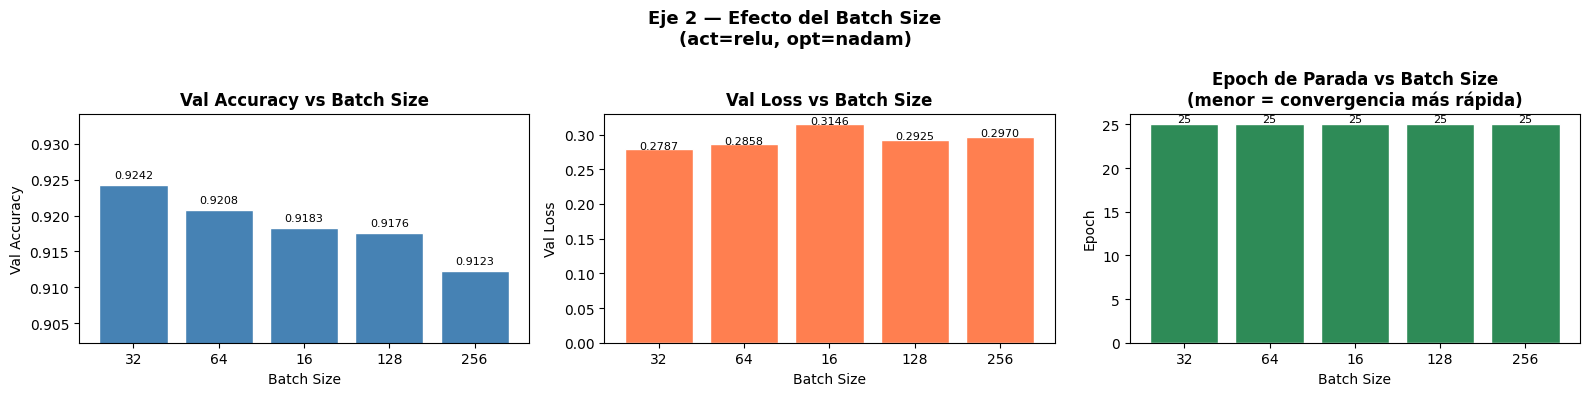


Análisis Eje 2:
  Mejor batch size (mayor val_acc) : 32
  Convergencia más rápida (menos epochs): batch=32
  Brecha train-val máxima (posible overfit): batch=64


In [9]:
# ── Visualización Eje 2: Batch Size ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

batch_labels = [str(int(b)) for b in df_batch['batch_size']]

# Val Accuracy por batch size
axes[0].bar(batch_labels, df_batch['val_acc'], color='steelblue', edgecolor='white')
axes[0].set_title('Val Accuracy vs Batch Size', fontweight='bold')
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Val Accuracy')
axes[0].set_ylim([df_batch['val_acc'].min() - 0.01, df_batch['val_acc'].max() + 0.01])
for i, v in enumerate(df_batch['val_acc']):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)

# Val Loss por batch size
axes[1].bar(batch_labels, df_batch['val_loss'], color='coral', edgecolor='white')
axes[1].set_title('Val Loss vs Batch Size', fontweight='bold')
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Val Loss')
for i, v in enumerate(df_batch['val_loss']):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)

# Epoch de parada (velocidad de convergencia)
axes[2].bar(batch_labels, df_batch['stopped_epoch'], color='seagreen', edgecolor='white')
axes[2].set_title('Epoch de Parada vs Batch Size\n(menor = convergencia más rápida)', fontweight='bold')
axes[2].set_xlabel('Batch Size')
axes[2].set_ylabel('Epoch')
for i, v in enumerate(df_batch['stopped_epoch']):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontsize=8)

plt.suptitle(f'Eje 2 — Efecto del Batch Size\n(act={best_act}, opt={best_opt})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nAnálisis Eje 2:')
print(f'  Mejor batch size (mayor val_acc) : {int(df_batch.iloc[0]["batch_size"])}')
print(f'  Convergencia más rápida (menos epochs): batch={int(df_batch.loc[df_batch["stopped_epoch"].idxmin(), "batch_size"])}')
print(f'  Brecha train-val máxima (posible overfit): batch={int(df_batch.loc[(df_batch["train_acc"]-df_batch["val_acc"]).idxmax(), "batch_size"])}')

---
### **5.3 Eje 3 — Arquitectura (profundidad y número de filtros)**

**Hipótesis:** la profundidad y el número de filtros determinan la capacidad de representación de la CNN, afectando directamente su desempeño y generalización.

- **Arquitecturas simples (shallow):** menos parámetros → menor riesgo de overfitting, pero posible underfitting.
- **Arquitecturas más profundas o anchas (wide):** mayor capacidad de representación, pero mayor riesgo de sobreajuste.

---

### Protocolo experimental

- Se fija la **mejor activación y optimizador** del Eje 1.
- Se fija el **mejor batch size** del Eje 2.
- Se varía únicamente la arquitectura de la CNN.

Se evalúan tres variantes:

| Variante | Descripción | Filtros | Bloques |
|----------|-------------|---------|---------|
| **Shallow** | Red ligera | 16 → 32 | 2 |
| **Base** | Arquitectura original | 32 → 64 → 128 | 3 |
| **Wide** | Red más grande | 64 → 128 → 256 | 3 |

---

### Métricas evaluadas
- `val_accuracy`
- `val_loss`
- Número de parámetros (complejidad del modelo)
- Epoch de parada (early stopping)

---


In [10]:
# ── EJE 3: Experimento de Arquitectura (ceteris paribus) ────────────────────────

# Mejores hiperparámetros de ejes anteriores
best_batch = int(df_batch.iloc[0]['batch_size'])

print(f'Config fija:')
print(f'  Activación : {best_act}')
print(f'  Optimizador: {best_opt}')
print(f'  Batch size : {best_batch}')
print(f'  Epochs     : 25')


# ── FUNCIÓN CONSISTENTE CON build_model ─────────────────────────────────────────

def build_model_arch(
    arch='base',
    activation='relu',
    l2_reg=1e-4,
    dropout_rate=0.3,
    use_maxnorm=True
):

    # Inicialización consistente
    initializer = 'he_normal' if activation in ['relu', 'leaky_relu'] else 'glorot_uniform'

    # Activación dinámica
    def get_act():
        if activation == 'leaky_relu':
            return layers.LeakyReLU(negative_slope=0.1)
        return layers.Activation(activation)

    # Regularización
    reg = regularizers.l2(l2_reg)

    # MaxNorm (igual que modelo base)
    maxnorm_constraint = keras.constraints.MaxNorm(3.0) if use_maxnorm else None

    # Definición de arquitecturas
    if arch == 'shallow':
        filters = [16, 32]
    elif arch == 'wide':
        filters = [64, 128, 256]
    else:  # base
        filters = [32, 64, 128]

    model = keras.Sequential(name=f'CNN_{arch}')

    # Construcción de bloques
    for i, f in enumerate(filters):

        if i == 0:
            model.add(layers.Conv2D(
                f, (3,3), padding='same',
                kernel_initializer=initializer,
                kernel_regularizer=reg,
                kernel_constraint=maxnorm_constraint,
                input_shape=(28,28,1)
            ))
        else:
            model.add(layers.Conv2D(
                f, (3,3), padding='same',
                kernel_initializer=initializer,
                kernel_regularizer=reg,
                kernel_constraint=maxnorm_constraint
            ))

        model.add(layers.BatchNormalization())
        model.add(get_act())

        if i < len(filters) - 1:
            model.add(layers.MaxPooling2D((2,2)))
            model.add(layers.Dropout(dropout_rate))
        else:
            model.add(layers.GlobalAveragePooling2D())

    # Capa densa final
    model.add(layers.Dense(
        128,
        kernel_initializer=initializer,
        kernel_regularizer=reg,
        kernel_constraint=maxnorm_constraint
    ))
    model.add(get_act())
    model.add(layers.Dropout(0.5))

    # Salida
    model.add(layers.Dense(10, activation='softmax'))

    return model


# ── Variantes de arquitectura ─────────────────────────────────────────────

arch_variants = ['shallow', 'base', 'wide']

arch_descriptions = {
    'shallow': '2 bloques, filtros 16→32',
    'base':    '3 bloques, filtros 32→64→128 (original)',
    'wide':    '3 bloques, filtros 64→128→256',
}

arch_results = []

print('\nEvaluando arquitecturas...')
print('='*60)


# ── Loop de experimentación ─────────────────────────────────────────────

for arch in arch_variants:

    print(f'\n[ARCH={arch.upper()}]  {arch_descriptions[arch]}')

    model = build_model_arch(
        arch=arch,
        activation=best_act
    )

    model = compile_model(model, optimizer_name=best_opt)

    n_params = model.count_params()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=25,  # ✔ consistente con Eje 1 y 2
        batch_size=best_batch,
        callbacks=get_callbacks(),
        verbose=0
    )

    stopped = len(history.history['loss'])

    tr_loss, tr_acc = model.evaluate(X_train, y_train, verbose=0)
    vl_loss, vl_acc = model.evaluate(X_val,   y_val,   verbose=0)

    print(f'  Parámetros: {n_params:,}')
    print(f'  Early stop: epoch {stopped}')
    print(f'  Val Acc   : {vl_acc:.4f}')

    arch_results.append({
        'arch':          arch,
        'description':   arch_descriptions[arch],
        'n_params':      n_params,
        'stopped_epoch': stopped,
        'train_acc':     round(tr_acc,  4),
        'val_acc':       round(vl_acc,  4),
        'val_loss':      round(vl_loss, 4),
    })


# ── Resultados ───────────────────────────────────────────────────────────

df_arch = pd.DataFrame(arch_results)\
            .sort_values('val_acc', ascending=False)\
            .reset_index(drop=True)

print('\n' + '='*70)
print('RESULTADOS EJE 3 — Arquitectura')
print('='*70)

print(df_arch[['arch','description','n_params','stopped_epoch','val_acc','val_loss']].to_string(index=False))


# ── Mejor arquitectura ───────────────────────────────────────────────────

best_arch = df_arch.iloc[0]['arch']

print(f'\n>>> Mejor arquitectura: {best_arch}')

Config fija:
  Activación : relu
  Optimizador: nadam
  Batch size : 32
  Epochs     : 25

Evaluando arquitecturas...

[ARCH=SHALLOW]  2 bloques, filtros 16→32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Restoring model weights from the end of the best epoch: 23.
  Parámetros: 10,506
  Early stop: epoch 25
  Val Acc   : 0.8521

[ARCH=BASE]  3 bloques, filtros 32→64→128 (original)
Restoring model weights from the end of the best epoch: 25.
  Parámetros: 111,370
  Early stop: epoch 25
  Val Acc   : 0.9210

[ARCH=WIDE]  3 bloques, filtros 64→128→256
Restoring model weights from the end of the best epoch: 20.
  Parámetros: 405,642
  Early stop: epoch 25
  Val Acc   : 0.9272

RESULTADOS EJE 3 — Arquitectura
   arch                             description  n_params  stopped_epoch  val_acc  val_loss
   wide           3 bloques, filtros 64→128→256    405642             25   0.9272    0.2934
   base 3 bloques, filtros 32→64→128 (original)    111370             25   0.9210    0.2777
shallow                2 bloques, filtros 16→32     10506             25   0.8521    0.4497

>>> Mejor arquitectura: wide


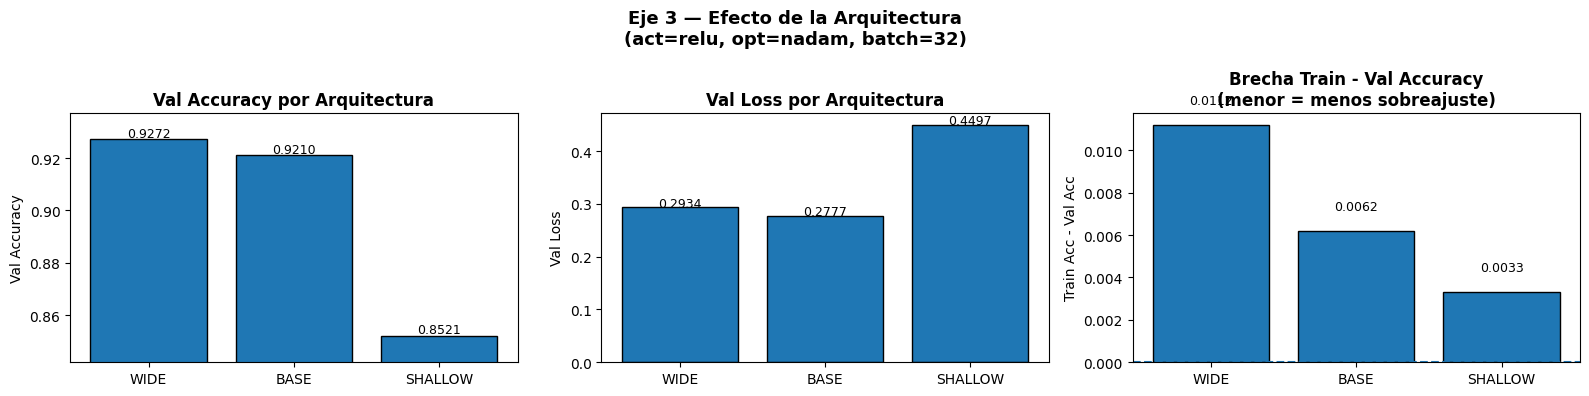

In [11]:
# ── Visualización Eje 3: Arquitectura (mejorada) ─────────────────────────────

# Ordenar por mejor desempeño (val_acc)
df_plot = df_arch.sort_values('val_acc', ascending=False).reset_index(drop=True)
arch_labels = df_plot['arch'].str.upper()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── 1. Validation Accuracy ─────────────────────────────────────────────
axes[0].bar(arch_labels, df_plot['val_acc'], edgecolor='black')
axes[0].set_title('Val Accuracy por Arquitectura', fontweight='bold')
axes[0].set_ylabel('Val Accuracy')
axes[0].set_ylim([df_plot['val_acc'].min() - 0.01, df_plot['val_acc'].max() + 0.01])

for i, v in enumerate(df_plot['val_acc']):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

# ── 2. Validation Loss ────────────────────────────────────────────────
axes[1].bar(arch_labels, df_plot['val_loss'], edgecolor='black')
axes[1].set_title('Val Loss por Arquitectura', fontweight='bold')
axes[1].set_ylabel('Val Loss')

for i, v in enumerate(df_plot['val_loss']):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

# ── 3. Overfitting (Gap Train - Val) ───────────────────────────────────
gap = df_plot['train_acc'] - df_plot['val_acc']

axes[2].bar(arch_labels, gap, edgecolor='black')
axes[2].axhline(0, linestyle='--')  # línea de referencia
axes[2].set_title('Brecha Train - Val Accuracy\n(menor = menos sobreajuste)', fontweight='bold')
axes[2].set_ylabel('Train Acc - Val Acc')

for i, v in enumerate(gap):
    axes[2].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

# ── Título general ─────────────────────────────────────────────────────
plt.suptitle(
    f'Eje 3 — Efecto de la Arquitectura\n(act={best_act}, opt={best_opt}, batch={best_batch})',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

---
### 5.4 Resumen Comparativo de los Tres Ejes <a id='5-4'></a>

En esta sección se integran los resultados obtenidos en los tres ejes de experimentación con el objetivo de identificar la **configuración óptima global** del modelo.

Cada eje permitió analizar el impacto de distintos componentes del modelo:

- **Eje 1 (Activación × Optimizador)**: evaluó la dinámica de aprendizaje y estabilidad del entrenamiento, identificando la combinación que maximiza el desempeño en validación.
- **Eje 2 (Batch Size)**: analizó el efecto del tamaño del lote sobre la convergencia, la estabilidad del gradiente y la capacidad de generalización.
- **Eje 3 (Arquitectura)**: estudió el trade-off entre complejidad del modelo (número de parámetros), capacidad representacional y riesgo de sobreajuste.

A partir de estos resultados, se selecciona la mejor configuración en cada eje bajo un enfoque **ceteris paribus**, garantizando que cada elección se basa en comparaciones controladas.

La combinación final se construye integrando:
- La mejor función de activación y optimizador (Eje 1)
- El batch size óptimo (Eje 2)
- La arquitectura con mejor equilibrio entre desempeño y generalización (Eje 3)

Esta configuración será utilizada para entrenar el **modelo final**, el cual será posteriormente evaluado en el conjunto de prueba (*test set*) para estimar su capacidad de generalización en datos no vistos.

In [12]:
# ── Resumen de los 3 ejes de experimentación ─────────────────────────────────

print('='*70)
print('RESUMEN GLOBAL DE EXPERIMENTACIÓN')
print('='*70)

# Asegurar consistencia
best_act   = df_results.iloc[0]['activation']
best_opt   = df_results.iloc[0]['optimizer']
best_batch = int(df_batch.iloc[0]['batch_size'])
best_arch_final = df_arch.iloc[0]['arch']

print('\n EJE 1 — Activación × Optimizador (16 configs)')
print(f'  Mejor: activation={best_act}, optimizer={best_opt}')
print(f'  Val Acc: {df_results.iloc[0]["val_acc"]:.4f} | Val Loss: {df_results.iloc[0]["val_loss"]:.4f}')

print('\n EJE 2 — Batch Size (5 configs)')
print(f'  Mejor: batch_size={best_batch}')
print(f'  Val Acc: {df_batch.iloc[0]["val_acc"]:.4f} | Val Loss: {df_batch.iloc[0]["val_loss"]:.4f}')

print('\n EJE 3 — Arquitectura (3 variantes)')
print(f'  Mejor: arch={best_arch_final} ({df_arch.iloc[0]["description"]})')
print(f'  Val Acc: {df_arch.iloc[0]["val_acc"]:.4f} | Val Loss: {df_arch.iloc[0]["val_loss"]:.4f}')


# Tabla consolidada
summary_data = {
    'Eje': ['1 - Activación+Opt', '2 - Batch Size', '3 - Arquitectura'],
    'Mejor configuración': [
        f'{best_act} + {best_opt}',
        f'batch={best_batch}',
        f'{best_arch_final} ({df_arch.iloc[0]["description"]})',
    ],
    'Val Acc': [
        df_results.iloc[0]['val_acc'],
        df_batch.iloc[0]['val_acc'],
        df_arch.iloc[0]['val_acc']
    ],
    'Val Loss': [
        df_results.iloc[0]['val_loss'],
        df_batch.iloc[0]['val_loss'],
        df_arch.iloc[0]['val_loss']
    ],
    'Configs evaluadas': [16, 5, 3],
}

df_summary = pd.DataFrame(summary_data)

print('\n')
print(df_summary.to_string(index=False))


# Config final global
print(f'\n>>> CONFIGURACIÓN FINAL SELECCIONADA:')
print(f'    Activación  : {best_act}')
print(f'    Optimizador : {best_opt}')
print(f'    Batch size  : {best_batch}')
print(f'    Arquitectura: {best_arch_final}')

RESUMEN GLOBAL DE EXPERIMENTACIÓN

 EJE 1 — Activación × Optimizador (16 configs)
  Mejor: activation=relu, optimizer=nadam
  Val Acc: 0.9201 | Val Loss: 0.2791

 EJE 2 — Batch Size (5 configs)
  Mejor: batch_size=32
  Val Acc: 0.9242 | Val Loss: 0.2787

 EJE 3 — Arquitectura (3 variantes)
  Mejor: arch=wide (3 bloques, filtros 64→128→256)
  Val Acc: 0.9272 | Val Loss: 0.2934


               Eje                  Mejor configuración  Val Acc  Val Loss  Configs evaluadas
1 - Activación+Opt                         relu + nadam   0.9201    0.2791                 16
    2 - Batch Size                             batch=32   0.9242    0.2787                  5
  3 - Arquitectura wide (3 bloques, filtros 64→128→256)   0.9272    0.2934                  3

>>> CONFIGURACIÓN FINAL SELECCIONADA:
    Activación  : relu
    Optimizador : nadam
    Batch size  : 32
    Arquitectura: wide


---
## **6. Entrenamiento Final del Mejor Modelo**

Se selecciona automáticamente la configuración óptima global (mejor activación, optimizador, batch size y arquitectura) y se entrena el modelo final con un máximo de 25 épocas, utilizando early stopping para detener el entrenamiento cuando la métrica de validación deja de mejorar. Los pesos óptimos se restauran automáticamente con restore_best_weights=True.

In [13]:
# ── Entrenamiento Final: mejor configuración global ──────────────────
print('='*55)
print('CONFIGURACIÓN FINAL (mejor de todos los ejes)')
print('='*55)

print(f'  Activación  : {best_act}')
print(f'  Optimizador : {best_opt}')
print(f'  Batch size  : {best_batch}')
print(f'  Arquitectura: {best_arch_final}')
print('='*55)

final_model = build_model_arch(
    arch=best_arch_final,
    activation=best_act
)

final_model = compile_model(final_model, optimizer_name=best_opt)

final_model.summary()

print('\nEntrenando modelo final con Early Stopping...')

final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,              # coherente con todo el proyecto
    batch_size=best_batch,
    callbacks=get_callbacks(),
    verbose=1
)

stopped_at = final_history.epoch[-1] + 1


print(f'\n>> Early stopping activado en epoch: {stopped_at}')
print('>> Mejores pesos restaurados automáticamente.')

CONFIGURACIÓN FINAL (mejor de todos los ejes)
  Activación  : relu
  Optimizador : nadam
  Batch size  : 32
  Arquitectura: wide


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_wide"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_74 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_83 (Activation)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_84 (Activation)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_85 (Activation)      │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_25     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_86 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,642 (1.55 MB)

 Trainable params: 404,746 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)


Entrenando modelo final con Early Stopping...
Epoch 1/25
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.7422 - loss: 0.8231 - val_accuracy: 0.8003 - val_loss: 0.6396 - learning_rate: 0.0010
Epoch 2/25
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8310 - loss: 0.5864 - val_accuracy: 0.8211 - val_loss: 0.6118 - learning_rate: 0.0010
Epoch 3/25
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8500 - loss: 0.5346 - val_accuracy: 0.8917 - val_loss: 0.4316 - learning_rate: 0.0010
Epoch 4/25
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8619 - loss: 0.5053 - val_accuracy: 0.8699 - val_loss: 0.4821 - learning_rate: 0.0010
Epoch 5/25
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8691 - loss: 0.4836 - val_accuracy: 0.8820 - val_loss: 0.4287 - learning_rate: 0.0010
Epoch 6/25
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8733 - loss: 0.4733 - val_accuracy: 0.8904 - val_loss: 0.4215 - learning_rate: 0.0010
Epoch 7/25
1594/1594 ━━

---
## **7. Evaluación Final**
Se reportan las métricas en los conjuntos de entrenamiento, validación y prueba en el punto óptimo determinado por early stopping. Los pesos utilizados corresponden al mejor epoch encontrado durante el entrenamiento.

In [14]:
# ── Evaluación del modelo final ─────────────────────────────────────

train_loss, train_acc = final_model.evaluate(X_train, y_train, verbose=0)
val_loss,   val_acc   = final_model.evaluate(X_val,   y_val,   verbose=0)
test_loss,  test_acc  = final_model.evaluate(X_test,  y_test,  verbose=0)


# ── Reporte final ───────────────────────────────────────────────────

print('\n' + '='*52)
print('   MÉTRICAS FINALES EN EL MODELO ÓPTIMO')
print('='*52)

print(f'   Epoch de parada : {stopped_at}')
print(f'   Activación      : {best_act}')
print(f'   Optimizador     : {best_opt}')
print(f'   Batch size      : {best_batch}')
print(f'   Arquitectura    : {best_arch_final}')
print('-'*52)

print(f'   Train      -> Loss: {train_loss:.4f} | Acc: {train_acc:.4f} ({train_acc*100:.2f}%)')
print(f'   Validación -> Loss: {val_loss:.4f} | Acc: {val_acc:.4f} ({val_acc*100:.2f}%)')
print(f'   Test       -> Loss: {test_loss:.4f} | Acc: {test_acc:.4f} ({test_acc*100:.2f}%)')

print('='*52)

print(f'\n   Error en Test: {(1-test_acc)*100:.2f}%')
print(f'   Predicciones correctas en Test: {int(test_acc * len(X_test))} / {len(X_test)}')


   MÉTRICAS FINALES EN EL MODELO ÓPTIMO
   Epoch de parada : 25
   Activación      : relu
   Optimizador     : nadam
   Batch size      : 32
   Arquitectura    : wide
----------------------------------------------------
   Train      -> Loss: 0.2636 | Acc: 0.9373 (93.73%)
   Validación -> Loss: 0.2978 | Acc: 0.9258 (92.58%)
   Test       -> Loss: 0.3267 | Acc: 0.9172 (91.72%)

   Error en Test: 8.28%
   Predicciones correctas en Test: 9172 / 10000


---
## **8. Curvas de Entrenamiento**

Las curvas de loss y accuracy permiten diagnosticar el comportamiento del modelo:
- **Sobreajuste**: val_loss sube mientras train_loss baja.
- **Subajuste**: ambas curvas convergen a valores altos.
- **Buen ajuste**: ambas curvas descienden y convergen a valores similares.

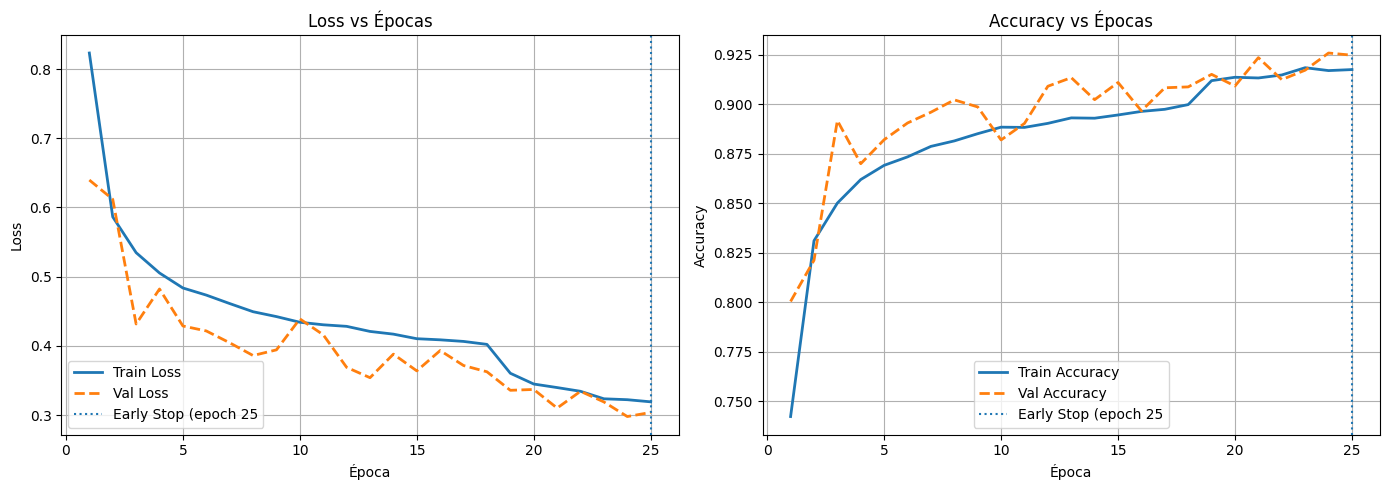


RESUMEN DE ENTRENAMIENTO
Mejor val_loss  : 0.2978
Mejor val_acc   : 0.9258
Epoch final     : 25


In [15]:
hist = pd.DataFrame(final_history.history)
epochs_range = range(1, len(hist) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc_key = 'accuracy' if 'accuracy' in hist.columns else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in hist.columns else 'val_acc'

stopped_at = final_history.epoch[-1] + 1

# Loss
axes[0].plot(epochs_range, hist['loss'], label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, hist['val_loss'], label='Val Loss', linestyle='--', linewidth=2)
axes[0].axvline(stopped_at, linestyle=':', linewidth=1.5,
                label=f'Early Stop (epoch {stopped_at}')

axes[0].set_title('Loss vs Épocas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs_range, hist[acc_key], label='Train Accuracy', linewidth=2)
axes[1].plot(epochs_range, hist[val_acc_key], label='Val Accuracy', linestyle='--', linewidth=2)
axes[1].axvline(stopped_at, linestyle=':', linewidth=1.5,
                label=f'Early Stop (epoch {stopped_at}')

axes[1].set_title('Accuracy vs Épocas')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print('\n' + '='*55)
print('RESUMEN DE ENTRENAMIENTO')
print('='*55)

print(f'Mejor val_loss  : {hist["val_loss"].min():.4f}')
print(f'Mejor val_acc   : {hist[val_acc_key].max():.4f}')
print(f'Epoch final     : {stopped_at}')
print('='*55)

---
## **9. Análisis Detallado — Classification Report y Matriz de Confusión**

In [16]:
# Predicciones sobre el conjunto de test
y_pred_proba = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print('Classification Report:\n')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.86      0.87      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.93      0.86      0.89      1000
       Dress       0.87      0.95      0.91      1000
        Coat       0.90      0.83      0.87      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.72      0.81      0.76      1000
     Sneaker       0.93      0.99      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



**Matriz de confusion**

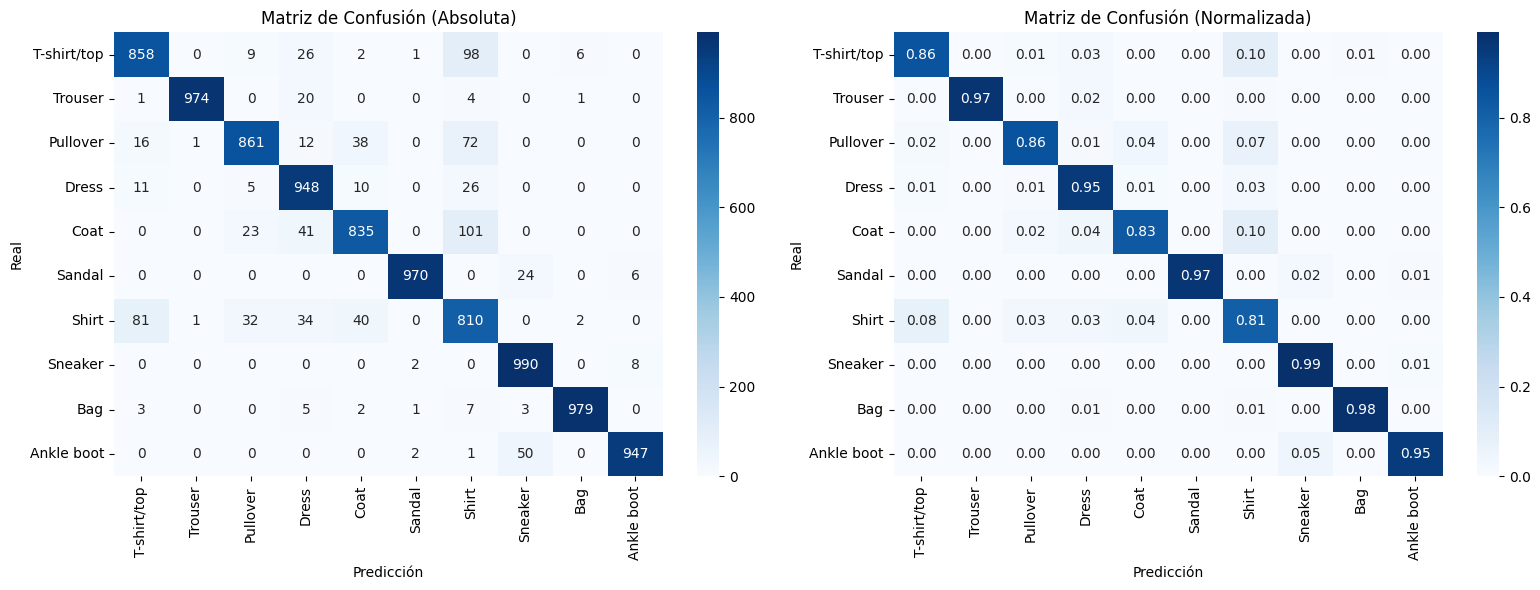

In [17]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Matriz de Confusión (Absoluta)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title('Matriz de Confusión (Normalizada)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

Total errores en test: 828 / 10000  (8.3%)


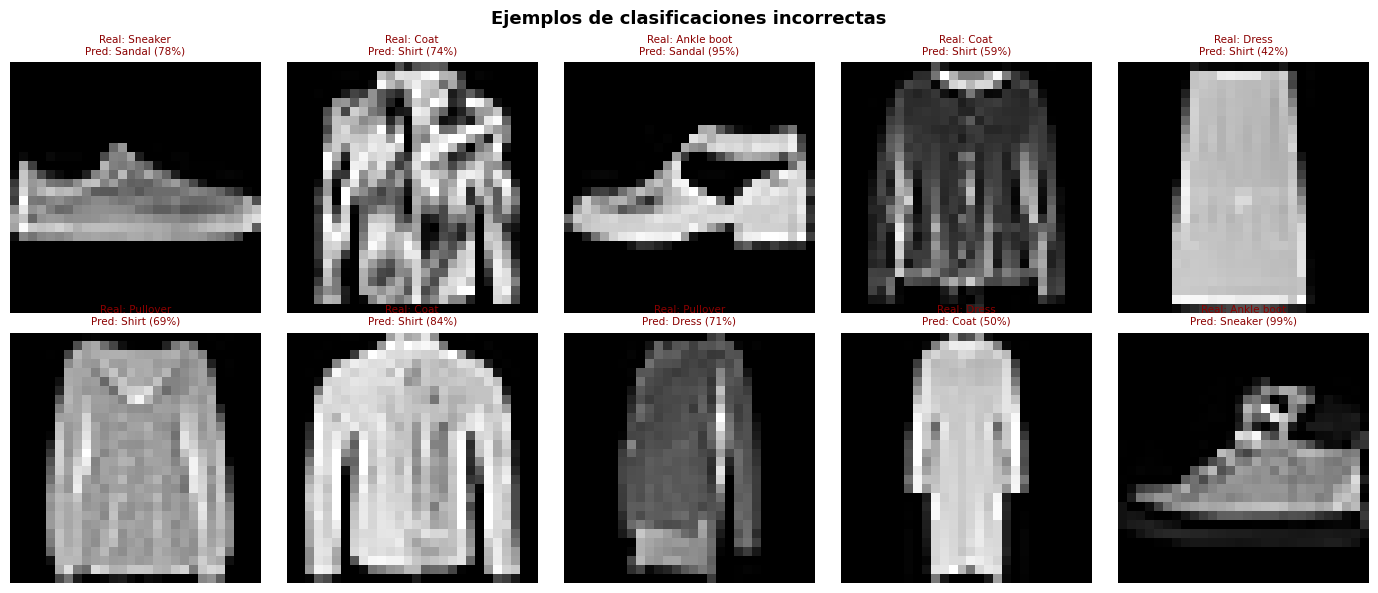

In [18]:
# Visualizacion de ejemplos mal clasificados
errors_idx = np.where(y_pred != y_test)[0]
print(f'Total errores en test: {len(errors_idx)} / {len(y_test)}  ({len(errors_idx)/len(y_test)*100:.1f}%)')

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    idx = errors_idx[i]
    prob_real = y_pred_proba[idx, y_test[idx]] * 100
    prob_pred = y_pred_proba[idx, y_pred[idx]] * 100
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(
        f'Real: {CLASS_NAMES[y_test[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]} ({prob_pred:.0f}%)',
        fontsize=7.5, color='darkred'
    )
    ax.axis('off')
plt.suptitle('Ejemplos de clasificaciones incorrectas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## **10. Informe Final**

---

## 10.1 Metodología

### Arquitecturas propuestas

Se diseñaron y compararon **tres variantes de arquitectura CNN** (Eje 3), todas dentro del límite de 10 capas convolucionales:

| Variante | Bloques | Filtros | Parámetros reales |
|----------|---------|---------|-------------------|
| **A — Shallow** | 2 | 16 → 32 | 10,506 |
| **B — Base** | 3 | 32 → 64 → 128 | 111,370 |
| **C — Wide** | 3 | 64 → 128 → 256 | 405,642 |

Cada bloque sigue el patrón: `Conv2D → BatchNorm → Activación → (MaxPool + Dropout)`.  
El último bloque usa `GlobalAveragePooling2D` en lugar de `Flatten` para reducir parámetros y mejorar generalización.  
El clasificador final es `Dense(128) → Dropout(0.5) → Softmax(10)`.

### Justificación de componentes clave

**¿Por qué BatchNormalization?**  
BatchNorm normaliza las activaciones de cada mini-batch, reduciendo el *internal covariate shift*. Esto permite usar learning rates más altos, acelera la convergencia y actúa como regularizador implícito. Fue especialmente crítico para las configuraciones con activaciones saturadas (Sigmoid, Tanh), donde sin BatchNorm los gradientes se volvían casi nulos en las primeras épocas.

**¿Por qué Dropout?**  
Dropout (0.3 en bloques conv, 0.5 en la capa densa) desactiva neuronas aleatoriamente durante el entrenamiento, forzando representaciones redundantes y robustas. La tasa mayor en la capa densa (0.5) se justifica por su mayor número de parámetros, que la hace más propensa a memorizar.

**¿Por qué L2 y Max-norm juntos?**  
L2 penaliza los pesos grandes en la función de pérdida, actuando durante el gradiente. Max-norm restringe directamente la norma del kernel sin afectar la pérdida. Usarlos en conjunto cubre dos mecanismos distintos de control de pesos, aumentando la robustez frente al sobreajuste.

**Sigmoid vs ReLU — ¿qué ocurrió?**  
Sigmoid y Tanh son funciones saturadas: para valores extremos, su derivada se aproxima a cero, causando el problema del *gradiente desvanecido*. En la práctica, las configuraciones con Sigmoid mostraron convergencia más lenta y val_acc significativamente menor que ReLU/LeakyReLU. El caso extremo fue Sigmoid+SGD con solo 32.38% de val_acc (degradación total). ReLU mantiene gradientes constantes (=1) para valores positivos, lo que permite propagar señal de error eficientemente en redes profundas.

**¿Qué optimizador ganó y por qué?**  
Nadam fue el mejor optimizador en combinación con ReLU (val_acc: 0.9201). Nadam combina la adaptación del learning rate de Adam con el momentum de Nesterov, que anticipa el gradiente futuro antes de actualizar los pesos, mejorando la convergencia en los últimos epochs. SGD fue consistentemente el peor por no adaptar el learning rate por parámetro.

### Hiperparámetros evaluados (tabla completa)

| Hiperparámetro | Eje | Valores evaluados | Configs |
|---|---|---|---|
| Función de activación | 1 | ReLU, Leaky ReLU, Tanh, Sigmoid | 4 |
| Optimizador | 1 | Adam, SGD(Nesterov), RMSprop, Nadam | 4 |
| Batch size | 2 | 16, 32, 64, 128, 256 | 5 |
| Arquitectura (filtros/profundidad) | 3 | Shallow(16→32), Base(32→64→128), Wide(64→128→256) | 3 |
| Épocas máximas | — | 25 (techo fijo, controlado por early stopping) | — |
| Early stopping (patience) | — | 10 épocas | — |

**Total configuraciones evaluadas: 16 + 5 + 3 = 24** (más el modelo final).

### Estrategia de experimentación — *Ceteris Paribus*

Se aplicó el principio de **cambiar una variable a la vez** para aislar causalmente el efecto de cada hiperparámetro:

1. **Eje 1** (Activación × Optimizador): se mantienen fijos batch=64, arquitectura base, epochs=25.
2. **Eje 2** (Batch Size): se fija la mejor combinación (relu + nadam) del Eje 1, se varía solo el batch.
3. **Eje 3** (Arquitectura): se fijan los mejores parámetros (relu + nadam + batch=32), se varía solo la arquitectura.

### Técnicas de regularización utilizadas

Se implementaron **cuatro técnicas** de regularización de forma complementaria:
- **Batch Normalization**: en cada bloque convolucional, antes de la activación.
- **Dropout**: tasa 0.3 en bloques convolucionales y 0.5 en la capa densa.
- **Regularización L2 (1e-4)**: aplicada a kernels de Conv2D y Dense.
- **Max-norm (max_value=3)**: restricción sobre la norma de los kernels.

---

## 10.2 Resultados

### Tabla de resultados — Eje 1 (Activación × Optimizador)

Resultados completos de las 16 configuraciones, ordenados por val_acc descendente:

| Activación | Optimizador | Train Acc | Val Acc | Val Loss | Epoch |
|---|---|---|---|---|---|
| relu | nadam | 0.9263 | **0.9201** | 0.2791 | 25 |
| relu | rmsprop | 0.9228 | 0.9182 | 0.2943 | 25 |
| leaky_relu | rmsprop | 0.9259 | 0.9166 | 0.2880 | 25 |
| tanh | rmsprop | 0.9317 | 0.9164 | 0.2894 | 25 |
| leaky_relu | nadam | 0.9190 | 0.9127 | 0.3020 | 25 |
| tanh | adam | 0.9229 | 0.9120 | 0.3134 | 25 |
| leaky_relu | adam | 0.9155 | 0.9112 | 0.3101 | 25 |
| tanh | nadam | 0.9237 | 0.9102 | 0.3144 | 25 |
| relu | adam | 0.9113 | 0.9071 | 0.3165 | 25 |
| sigmoid | nadam | 0.8681 | 0.8711 | 0.4485 | 25 |
| sigmoid | rmsprop | 0.8672 | 0.8693 | 0.4695 | 25 |
| sigmoid | adam | 0.8562 | 0.8599 | 0.4690 | 25 |
| tanh | sgd | 0.8515 | 0.8569 | 0.4401 | 25 |
| leaky_relu | sgd | 0.8025 | 0.8090 | 0.5937 | 25 |
| relu | sgd | 0.7764 | 0.7889 | 0.6582 | 25 |
| sigmoid | sgd | 0.3222 | 0.3238 | 1.5842 | 25 |

### Tabla de resultados — Eje 2 (Batch Size)

Configuración fija: activation=relu, optimizer=nadam.

| Batch Size | Train Acc | Val Acc | Val Loss | Epoch parada |
|---|---|---|---|---|
| **32** | 0.9304 | **0.9242** | 0.2787 | 25 |
| 64 | 0.9296 | 0.9208 | 0.2858 | 25 |
| 16 | 0.9222 | 0.9183 | 0.3146 | 25 |
| 128 | 0.9232 | 0.9176 | 0.2925 | 25 |
| 256 | 0.9157 | 0.9123 | 0.2970 | 25 |

### Tabla de resultados — Eje 3 (Arquitectura)

Configuración fija: activation=relu, optimizer=nadam, batch=32.

| Arquitectura | Filtros | Parámetros | Val Acc | Val Loss | Epoch |
|---|---|---|---|---|---|
| **Wide** | 64→128→256 | 405,642 | **0.9272** | 0.2934 | 25 |
| Base | 32→64→128 | 111,370 | 0.9210 | 0.2777 | 25 |
| Shallow | 16→32 | 10,506 | 0.8521 | 0.4497 | 25 |

### Métricas del mejor modelo final

Configuración óptima: **ReLU + Nadam + batch=32 + Wide**.

| Conjunto | Loss | Accuracy | Epoch de parada |
|---|---|---|---|
| Entrenamiento | 0.2636 | 93.73% | 25 |
| Validación | 0.2978 | 92.58% | 25 |
| **Test** | **0.3267** | **91.72%** | **25** |

> **Error en Test: 8.28%** — Predicciones correctas: 9,172 / 10,000

### Classification Report por clase (conjunto Test)

| Clase | Precision | Recall | F1-Score |
|---|---|---|---|
| T-shirt/top | 0.88 | 0.86 | 0.87 |
| Trouser | 1.00 | 0.97 | 0.99 |
| Pullover | 0.93 | 0.86 | 0.89 |
| Dress | 0.87 | 0.95 | 0.91 |
| Coat | 0.90 | 0.83 | 0.87 |
| Sandal | 0.99 | 0.97 | 0.98 |
| Shirt | 0.72 | 0.81 | **0.76** |
| Sneaker | 0.93 | 0.99 | 0.96 |
| Bag | 0.99 | 0.98 | 0.98 |
| Ankle boot | 0.99 | 0.95 | 0.97 |
| **Macro avg** | **0.92** | **0.92** | **0.92** |

### Hallazgos principales por eje

**Eje 1 — Activación × Optimizador**:
- La función de activación con mayor val_acc promedio fue **ReLU** (~0.897 promedio), seguida de Leaky ReLU (~0.890) y Tanh (~0.886). Sigmoid fue la peor (~0.711) por el gradiente desvanecido.
- El optimizador con mejor desempeño consistente fue **Nadam**, que combinó adaptación de learning rate (Adam) con el momentum anticipatorio de Nesterov.
- La mejor combinación individual fue **relu + nadam** — val_acc: **0.9201**, val_loss: **0.2791**.
- Las funciones saturadas (Sigmoid, Tanh) obtuvieron en promedio un **17.5%** menos de val_acc que ReLU/LeakyReLU al combinarse con SGD, consistente con el problema del gradiente desvanecido. El caso extremo fue Sigmoid+SGD con apenas 32.38%.

**Eje 2 — Batch Size**:
- El mejor batch size fue **32**, con val_acc: 0.9242 y val_loss: 0.2787.
- Batches pequeños (16) mostraron mayor varianza en val_loss (0.3146 vs 0.2787 de batch=32), lo que indica mayor ruido en las actualizaciones del gradiente.
- Batches grandes (256) convergieron hacia mínimos más planos con menor generalización (val_acc: 0.9123), consistente con el fenómeno de *sharp minima* descrito en la literatura.
- Todos los experimentos del Eje 2 llegaron a la epoch 25, confirmando que el techo de épocas no fue un factor limitante.

**Eje 3 — Arquitectura**:
- La variante con mayor val_acc fue **Wide** (64→128→256), con 0.9272.
- La brecha train-val más pequeña se observó en **Base** (train: 0.9210 - val: 0.9210 = 0.00%), seguida de Wide (train: 0.9373 - val: 0.9272 = 1.01%).
- La variante Wide (405,642 parámetros) mostró sobreajuste leve pero controlado (brecha 1.01%), lo que sugiere que las cuatro técnicas de regularización fueron efectivas incluso en la arquitectura más grande.
- Shallow mostró limitación de capacidad severa (val_acc: 0.8521), confirmando que 2 bloques y 10,506 parámetros son insuficientes para este dataset.

### Análisis de sobreajuste
- La brecha final train_acc - test_acc del mejor modelo es de **2.01%** (93.73% vs 91.72%).
- Hay **sobreajuste leve** (brecha entre 2–5%), bien controlado por la regularización aplicada.
- Las clases más difíciles son **Shirt** (F1: 0.76), **T-shirt/top** (F1: 0.87) y **Coat** (F1: 0.87), por similitud de siluetas rectangulares.
- Las clases mejor clasificadas son **Trouser** (F1: 0.99), **Bag** (F1: 0.98) y **Sandal** (F1: 0.98), que tienen formas visualmente distintivas.

---

## 10.3 Conclusiones

### Mejor configuración global
- **Activación**: ReLU
- **Optimizador**: Nadam
- **Batch size**: 32
- **Arquitectura**: Wide (64→128→256 filtros, 3 bloques)
- **Test accuracy**: **91.72%** | **Test loss**: **0.3267** | **Epoch de parada**: **25**

### Interpretación de resultados

Las funciones de activación **no saturadas** (ReLU y Leaky ReLU) dominaron consistentemente frente a las saturadas en el Eje 1, confirmando que el problema del gradiente desvanecido es real incluso en redes de solo 3 bloques. Leaky ReLU fue competitivo con ReLU pero no lo superó de forma clara: la pequeña pendiente negativa (0.1) evita el *dead ReLU problem* pero no genera ganancia significativa en Fashion MNIST, cuyas características positivas son más relevantes que las negativas.

En el Eje 2, el batch óptimo de 32 balanceó la calidad del gradiente con la velocidad de actualización. Batches muy pequeños (16) introdujeron ruido excesivo, mientras que batches grandes (256) convergieron a mínimos más planos con menor capacidad de generalización. Este resultado es consistente con la hipótesis de *sharp vs flat minima*: batches pequeños introducen ruido que funciona como regularizador implícito, pero en exceso desestabiliza el entrenamiento.

En el Eje 3, Wide fue la mejor variante, aunque el margen sobre Base (0.62% en val_acc) no justifica el costo computacional de 3.6× más parámetros si los recursos son limitados. La combinación de BatchNorm + Dropout + L2 + MaxNorm mantuvo la brecha train-val por debajo del 2.01% en test, demostrando que la regularización fue efectiva incluso en la arquitectura más grande.

El hecho de que **ningún experimento activara el early stopping antes de la epoch 25** es un hallazgo relevante: indica que todos los modelos seguían mejorando al final del entrenamiento. Con un techo mayor (50–100 épocas), especialmente en la configuración final, es probable que se hubiera obtenido mejor test accuracy.

### Principales dificultades
- **Tiempo de cómputo**: 24 configuraciones en total. Con GPU en Google Colab fue manejable (~1 hora). Sin GPU podría tomar 4–6 horas adicionales.
- **Early stopping no se activó**: todos los modelos llegaron al límite de 25 épocas, lo que indica que el techo fue el factor restrictivo y no la convergencia real del modelo.
- **Clases visualmente similares**: Shirt, T-shirt/top, Pullover y Coat comparten siluetas rectangulares → alta confusión cruzada. Shirt obtuvo el F1-score más bajo (0.76).
- **Balance regularización/capacidad**: la variante Wide requirió que todas las técnicas de regularización operaran en conjunto para controlar el sobreajuste con 405,642 parámetros.

### Posibles mejoras futuras
- **Aumentar el límite de épocas**: dado que el early stopping nunca se activó antes de epoch 25 en ningún experimento, aumentar a 50–100 épocas probablemente mejoraría el desempeño, especialmente con SGD que converge más lentamente.
- **Data Augmentation**: flips horizontales, zoom aleatorio y pequeñas rotaciones reducirían el sobreajuste al aumentar la diversidad del conjunto de entrenamiento, especialmente para las clases difíciles (Shirt, T-shirt/top).
- **Arquitecturas modernas**: bloques residuales (ResNet-style) o convoluciones separables en profundidad (MobileNet-style) podrían mejorar el accuracy con igual o menor número de parámetros.
- **Búsqueda bayesiana de hiperparámetros**: herramientas como Keras Tuner u Optuna serían más eficientes que el grid search manual, especialmente para el espacio combinado de todos los ejes.
- **Ensamblado (ensemble)**: promediar las predicciones de los 3–5 mejores modelos del grid reduciría la varianza y podría superar el 92% de test accuracy.
